In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/Google_Stock_Price_Test.csv')

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.2434
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.2382
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.2318
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.2294
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.2256
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.2215
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.2177
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.2123
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.2073
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.2038
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.2000
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.1947
Epoch 13/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.1897
Epoch 14/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1882
Epoch 15/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1834
Epoch 16/20
1/1 ━━━━━━━━━━━━━━━━━━━━

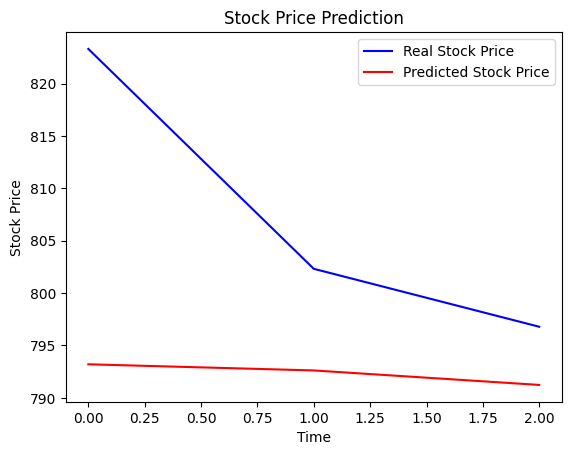

In [8]:

data = df['Close'].values
data = data.reshape(-1, 1)


scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# تقسیم‌بندی داده‌ها به مجموعه آموزشی و تست
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# ایجاد داده‌های ورودی و خروجی برای آموزش مدل
def create_dataset(data, n_steps=1): # Changed n_steps to 1
    X, y = [], []
    for i in range(n_steps, len(data)):
        X.append(data[i-n_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

n_steps = 1 # Changed n_steps to 1
X_train, y_train = create_dataset(train_data, n_steps)
X_test, y_test = create_dataset(test_data, n_steps)

# تغییر شکل داده‌ها برای مدل LSTM (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


model = Sequential()


model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))


model.add(Dense(units=1))


model.compile(optimizer='adam', loss='mean_squared_error')


model.fit(X_train, y_train, epochs=20, batch_size=32)

predicted_stock_price = model.predict(X_test)

# بازگرداندن مقادیر به حالت اولیه (denormalize)
predicted_stock_price = scaler.inverse_transform(predicted_stock_price)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# گام 6: ترسیم نتایج
plt.plot(y_test, color='blue', label='Real Stock Price')
plt.plot(predicted_stock_price, color='red', label='Predicted Stock Price')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()